# Development Feature and Market-Data Diagnostics

## TL;DR

- Audited **3,673 symbol-session rows**, **116 features**, and **5 development instruments**. The sealed holdout was not opened.
- Key integrity checks found **0 duplicate keys**, **0 invalid session OHLC rows**, and **0 constant features**.
- After the 120-session warm-up, **0 features** exceed 1% missingness.
- **76 feature-column pairs** have absolute correlation of at least 0.95; these are calculation-redundancy candidates, not instrument-removal signals.
- **0 features** show an early-versus-late median shift greater than one pooled IQR and require stability review.
- Current-contract labels appear to represent continuation histories; vendor roll/adjustment methodology remains a high-impact open question.


## Context & Methods

This is a development-only readiness audit for research features—not a strategy test. The intended grain is one row per symbol and trading session. Checks cover uniqueness, validity, completeness, outliers, redundancy, temporal drift, data coverage, and point-in-time boundaries.

### Key Assumptions

- Features may be used only after `feature_available_at_utc`.
- The first 120 observations per symbol are treated as expected indicator warm-up.
- A 0.95 absolute-correlation threshold identifies review candidates; it does not prove two features are economically interchangeable.
- Drift is descriptive: an early/late median shift above one pooled IQR is a review flag, not a statistical rejection.
- One-minute activity measures are bar-level proxies, not true tick or order-book pace.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
OUT = ROOT / "outputs"
panel = pd.read_parquet(ROOT / "data/processed/research/development_session_panel.parquet")
features = pd.read_parquet(ROOT / "data/processed/features/development_session_features.parquet")
meta = json.loads((ROOT / "data/catalog/development_features.json").read_text())
split = json.loads((ROOT / "data/catalog/temporal_split.json").read_text())
feature_columns = meta["feature_columns"]
family_lookup = {f: family for family, columns in meta["feature_families"].items() for f in columns}
features["trading_date"] = pd.to_datetime(features["trading_date"])
panel["trading_date"] = pd.to_datetime(panel["trading_date"])
assert features["trading_date"].max() <= pd.Timestamp(split["development_end"])
assert not features.duplicated(["symbol", "trading_date"]).any()
print(f"Development boundary verified through {features['trading_date'].max().date()}")
print(f"{len(features):,} rows | {len(feature_columns)} features | {features['symbol'].nunique()} symbols")

Development boundary verified through 2025-08-15
3,673 rows | 116 features | 5 symbols


## Data: grain, coverage, and session integrity

In [2]:
instrument = pd.read_csv(OUT / "instrument_quality_profile.csv")
instrument

,symbol,first_session,last_session,sessions,median_minutes,total_missing_minutes,zero_volume_sessions,invalid_ohlc_sessions,missing_minutes_per_session
0,CLU6,2022-10-12,2025-08-15,734,1370.0,9574,0,0,13.043597
1,HGU6,2022-10-12,2025-08-15,734,1330.0,47784,0,0,65.100817
2,NQU6,2022-10-12,2025-08-15,735,1365.0,8601,0,0,11.702041
3,ZNU6,2022-10-12,2025-08-15,735,1311.0,56305,0,0,76.605442
4,ZTU6,2022-10-12,2025-08-15,735,1171.0,154265,0,0,209.884354


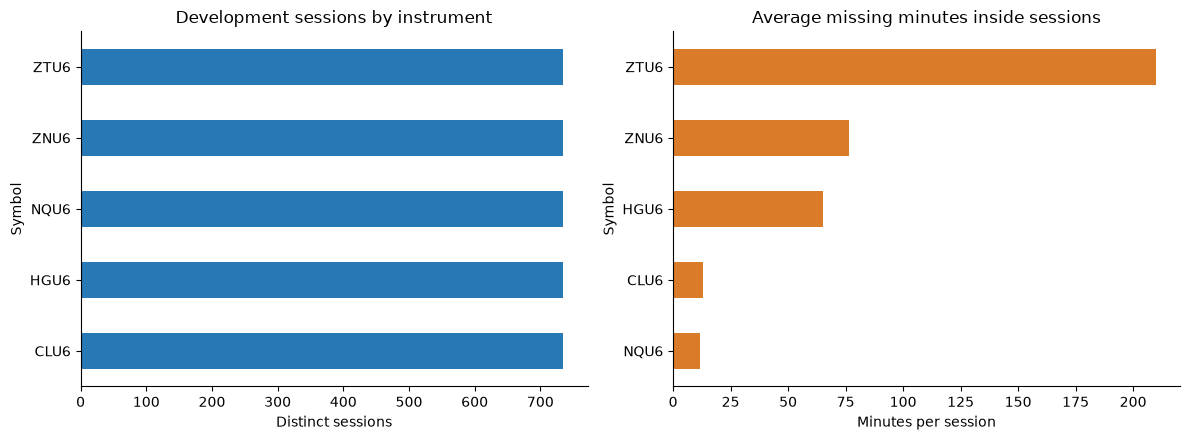

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
instrument.sort_values("sessions").plot.barh(x="symbol", y="sessions", ax=axes[0], color="#2878B5", legend=False)
axes[0].set(title="Development sessions by instrument", xlabel="Distinct sessions", ylabel="Symbol")
instrument.sort_values("missing_minutes_per_session").plot.barh(x="symbol", y="missing_minutes_per_session", ax=axes[1], color="#D97B29", legend=False)
axes[1].set(title="Average missing minutes inside sessions", xlabel="Minutes per session", ylabel="Symbol")
for ax in axes: ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "diagnostic_instrument_coverage.png", dpi=160)
plt.show()

## Feature completeness and expected warm-up

In [4]:
profile = pd.read_csv(OUT / "feature_quality_profile.csv")
profile.sort_values("missing_pct_after_warmup", ascending=False).head(20)

,family,feature,missing_pct_all,missing_pct_after_warmup,distinct_values,median,p01,p99,robust_outlier_pct
0,momentum_reversal,log_return_1s,0.136129,0.0,3634,0.000000,-0.052982,0.044885,3.026172
1,momentum_reversal,momentum_2s,0.272257,0.0,3663,0.000136,-0.072928,0.063323,2.921103
2,momentum_reversal,momentum_5s,0.680643,0.0,3648,0.000226,-0.117918,0.104828,2.796053
3,momentum_reversal,momentum_10s,1.361285,0.0,3623,0.000541,-0.149684,0.137444,1.959702
4,momentum_reversal,momentum_20s,2.722570,0.0,3572,0.001566,-0.170158,0.192470,1.511335
5,momentum_reversal,momentum_60s,8.167710,0.0,3372,0.002399,-0.226661,0.289231,0.770827
6,momentum_reversal,momentum_120s,16.335421,0.0,3073,0.003116,-0.172842,0.278315,0.357956
7,momentum_reversal,standardized_return_5s,0.680643,0.0,3648,0.035881,-3.235894,3.361176,0.109649
8,momentum_reversal,standardized_return_20s,2.722570,0.0,3572,0.098743,-2.103646,2.254446,0.000000
9,momentum_reversal,standardized_return_60s,8.167710,0.0,3372,0.058682,-1.894820,2.406599,0.000000


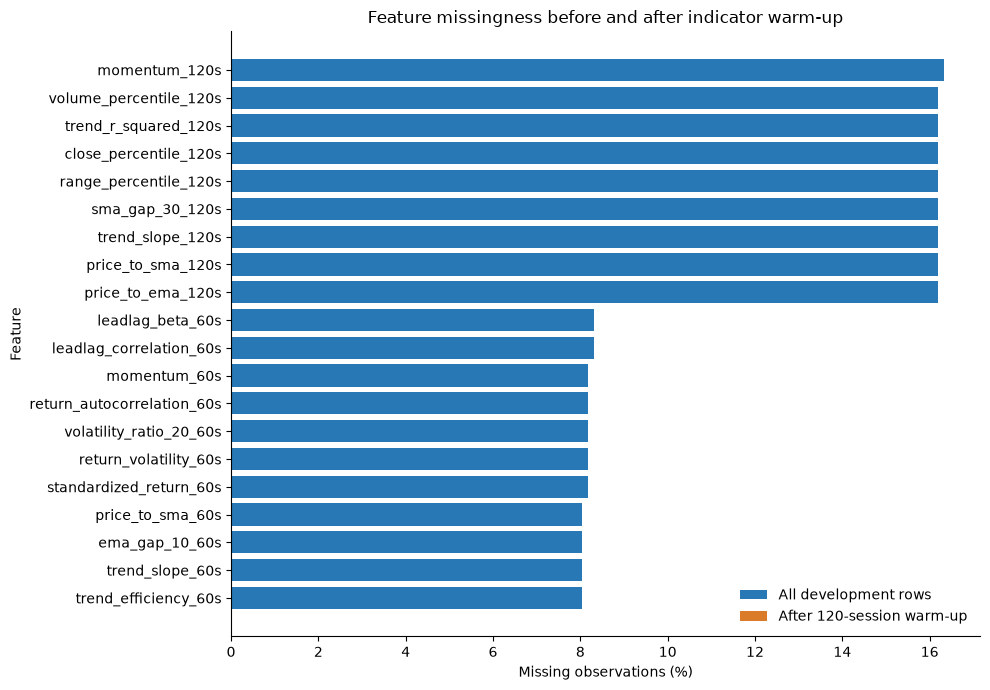

In [5]:
top_missing = profile.nlargest(20, "missing_pct_all").sort_values("missing_pct_all")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_missing["feature"], top_missing["missing_pct_all"], color="#2878B5", label="All development rows")
ax.barh(top_missing["feature"], top_missing["missing_pct_after_warmup"], color="#D97B29", label="After 120-session warm-up")
ax.set(title="Feature missingness before and after indicator warm-up", xlabel="Missing observations (%)", ylabel="Feature")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "diagnostic_feature_missingness.png", dpi=160)
plt.show()

## Redundancy is concentrated and should be pruned by family

In [6]:
redundancy = pd.read_csv(OUT / "feature_redundancy_pairs.csv")
redundancy.head(25)

,feature_a,feature_b,correlation,absolute_correlation
0,log_return_1s,reversal_1s,-1.000000,1.000000
1,overnight_gap_fraction,open_to_previous_close,1.000000,1.000000
2,parkinson_volatility_30s,garman_klass_volatility_30s,0.998421,0.998421
3,parkinson_volatility_20s,garman_klass_volatility_20s,0.997730,0.997730
4,atr_5s_fraction,parkinson_volatility_5s,0.994341,0.994341
5,range_fraction,true_range_fraction,0.994050,0.994050
6,parkinson_volatility_5s,garman_klass_volatility_5s,0.993726,0.993726
7,zero_return_fraction,positive_return_fraction,-0.993322,0.993322
8,absolute_return_per_observed_minute,intraday_return_q10,-0.991622,0.991622
9,absolute_return_per_observed_minute,intraday_return_q90,0.991235,0.991235


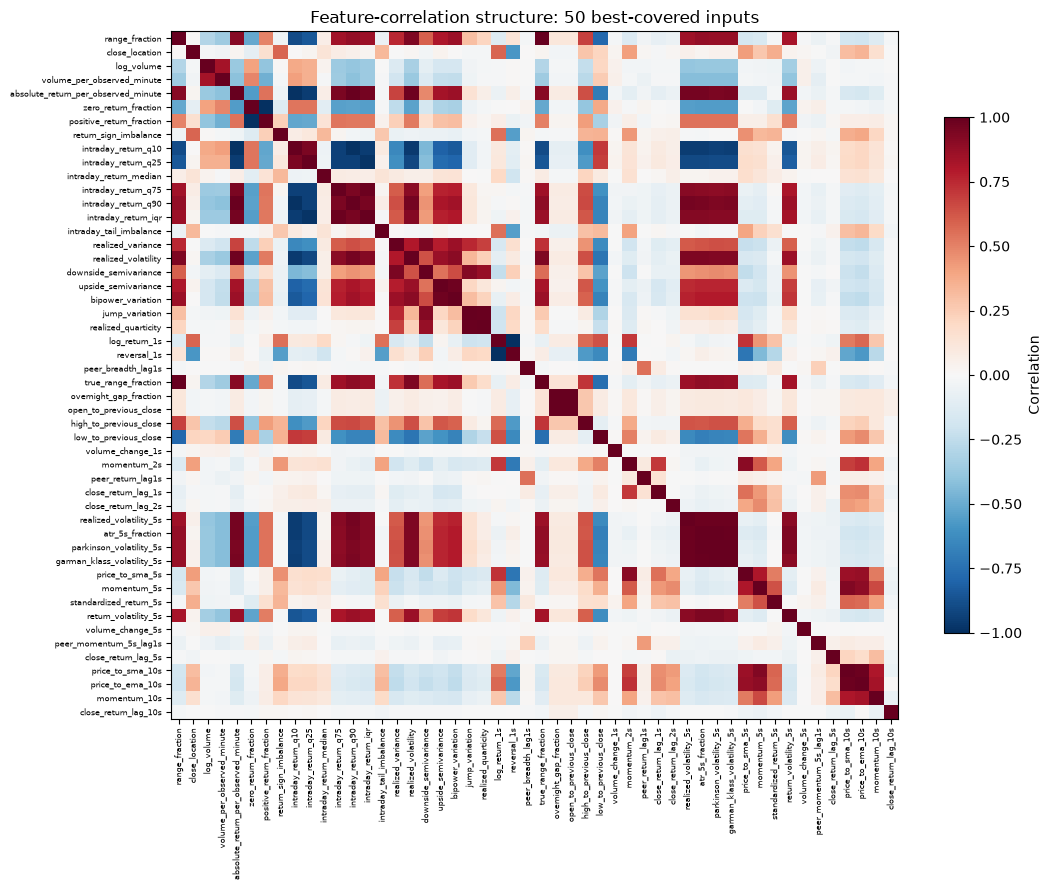

In [7]:
numeric = features[feature_columns].replace([np.inf, -np.inf], np.nan)
ranked = numeric.notna().sum().nlargest(50).index
corr = numeric[ranked].corr(min_periods=200)
fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(len(ranked)), ranked, rotation=90, fontsize=6)
ax.set_yticks(range(len(ranked)), ranked, fontsize=6)
ax.set_title("Feature-correlation structure: 50 best-covered inputs")
fig.colorbar(image, ax=ax, label="Correlation", shrink=0.75)
fig.tight_layout()
fig.savefig(OUT / "diagnostic_feature_correlation.png", dpi=180)
plt.show()

## Temporal drift identifies features requiring stability controls

In [8]:
drift = pd.read_csv(OUT / "feature_drift_profile.csv")
drift.head(20)

,family,feature,early_observations,late_observations,early_median,late_median,median_shift_in_iqr
0,ohlcv_history,close_percentile_120s,628,1225,0.320833,0.583333,0.388889
1,volatility_liquidity_regime,return_autocorrelation_60s,628,1225,-0.012188,-0.070518,0.370749
2,ohlcv_history,close_percentile_60s,628,1225,0.358333,0.600000,0.345238
3,range_atr_and_estimators,range_percentile_120s,628,1225,0.366667,0.508333,0.274194
4,cross_market_lead_lag,leadlag_correlation_60s,628,1225,0.018446,-0.021665,0.234083
5,ohlcv_history,close_percentile_20s,628,1225,0.450000,0.600000,0.230769
6,volatility_liquidity_regime,return_autocorrelation_20s,628,1225,-0.023964,-0.088477,0.230631
7,momentum_reversal,standardized_return_20s,628,1225,-0.121560,0.169703,0.223211
8,moving_average_structure,price_to_sma_120s,628,1225,-0.009740,0.002003,0.218435
9,cross_market_lead_lag,leadlag_correlation_20s,628,1225,0.048145,-0.017832,0.196414


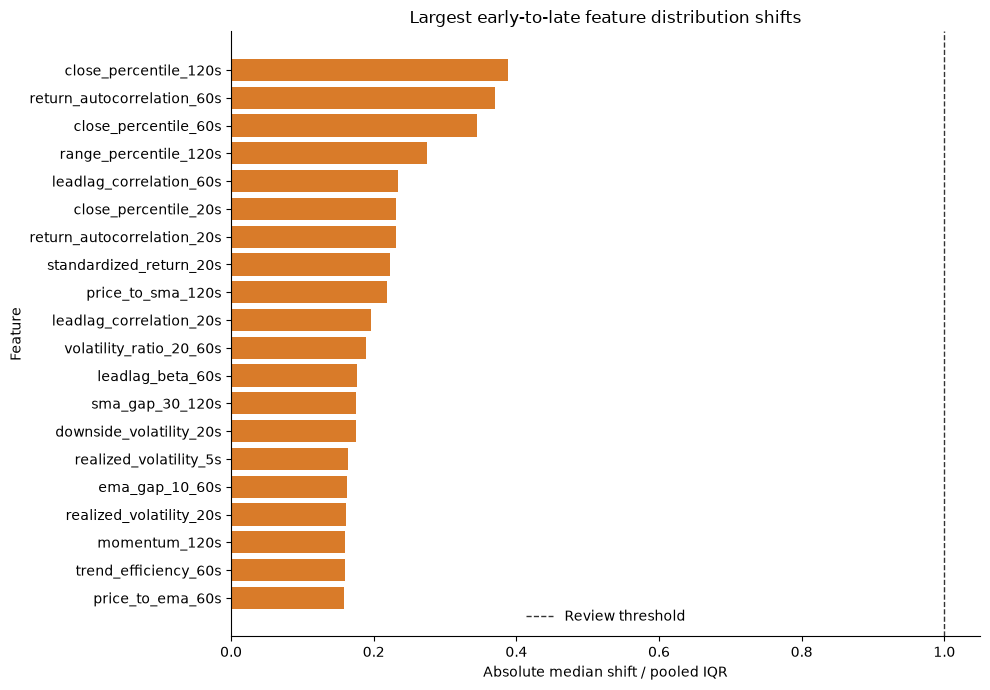

In [9]:
top_drift = drift.dropna(subset=["median_shift_in_iqr"]).head(20).sort_values("median_shift_in_iqr")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_drift["feature"], top_drift["median_shift_in_iqr"], color="#D97B29")
ax.axvline(1.0, color="#333333", linestyle="--", linewidth=1, label="Review threshold")
ax.set(title="Largest early-to-late feature distribution shifts", xlabel="Absolute median shift / pooled IQR", ylabel="Feature")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "diagnostic_feature_drift.png", dpi=160)
plt.show()

## Return and regime shape by instrument

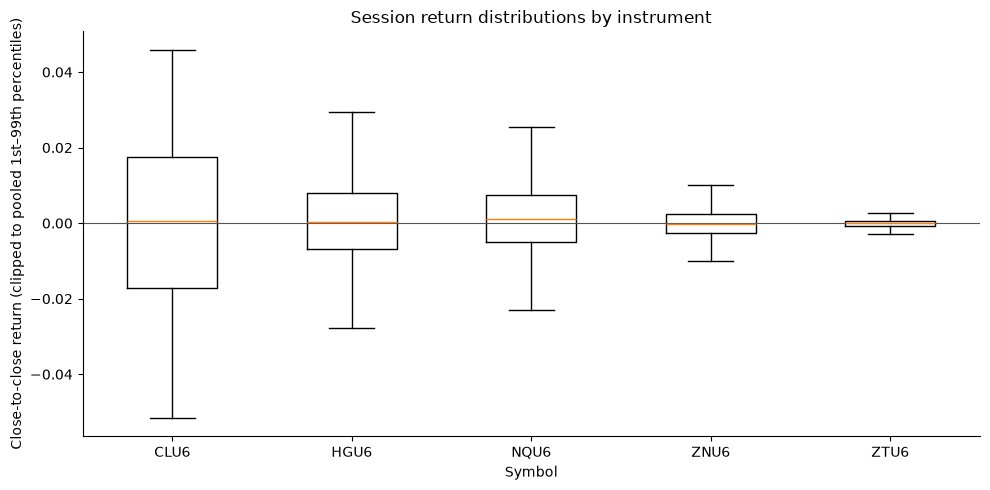

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
symbol,,,,,,,,,,,,
CLU6,733.0,0.000183,0.028616,-0.113443,-0.074547,-0.049003,-0.017153,0.000531,0.017615,0.043523,0.066791,0.107796
HGU6,733.0,0.000305,0.015120,-0.172919,-0.039924,-0.019608,-0.006937,0.000213,0.007935,0.019765,0.036106,0.094445
NQU6,734.0,0.000835,0.011752,-0.056638,-0.028655,-0.017708,-0.004939,0.001187,0.007416,0.017498,0.026137,0.115008
ZNU6,734.0,-0.000037,0.004070,-0.012456,-0.009196,-0.006163,-0.002680,-0.000280,0.002483,0.006554,0.011661,0.017094
ZTU6,734.0,-0.000034,0.001396,-0.005268,-0.003475,-0.002032,-0.000786,-0.000077,0.000645,0.002055,0.004414,0.011379


In [10]:
returns = panel.pivot(index="trading_date", columns="symbol", values="close_to_close_return")
lower, upper = returns.stack().quantile([0.01, 0.99])
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([returns[c].dropna().clip(lower, upper) for c in returns], tick_labels=returns.columns, showfliers=False)
ax.axhline(0, color="#555555", linewidth=0.8)
ax.set(title="Session return distributions by instrument", xlabel="Symbol", ylabel="Close-to-close return (clipped to pooled 1st–99th percentiles)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "diagnostic_return_distributions.png", dpi=160)
plt.show()
returns.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

## Limitations, uncertainty, and robustness checks

- The audit confirms internal consistency, not vendor correctness. Historical roll/adjustment methodology must be obtained from Investor/RT before using continuation histories for P&L simulation.
- ES and GC are holdout-only with the current files and are intentionally absent from development diagnostics.
- 6J remains quarantined because its price series was constant at 0.01.
- Implied-volatility spreads cannot be calculated without point-in-time options data.
- One-minute OHLCV cannot establish genuine trade-count, bid/ask, order-flow, or message-rate features.
- High feature correlation and distribution drift require pruning and stability rules before model fitting.


## Recommended next steps

1. Confirm continuation-series roll and price-adjustment rules with the data vendor.
2. Preserve correlated and inversely correlated instruments for relative-value and lead/lag research. Separately review highly correlated **feature columns** and retain one economically interpretable calculation per redundant cluster.
3. Establish feature winsorization, scaling, and missing-value policies using development data only.
4. Add older ES/GC history and a valid 6J series, then rerun this notebook.
5. Only after these controls are frozen, define forward returns and begin sequential walk-forward evaluation.

## Further questions

- Are the exported histories back-adjusted, ratio-adjusted, or unadjusted stitched contracts?
- Does exported volume represent actual contract volume consistently across roll boundaries?
- Will options-chain, bid/ask, or trade-count data become available for IV and true tape diagnostics?

Instrument correlation is intentional in this research universe. It will later support spreads, residual returns, relative momentum, confirmation/divergence, hedge ratios, and changing-correlation regimes; it is not a reason to discard a market.
